In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter, FixedLocator
from matplotlib.font_manager import FontProperties
from pathlib import Path

In [16]:
newmethods = {
    'unitvelo_ind': 'UniTVelo (ind)',
    'velovi': 'veloVI',
    'cell2fate': 'cell2fate',
    'latentvelo_std': 'LatentVelo (std)',
    'pyrovelocity_m1': 'Pyro-velocity (m1)',
    'pyrovelocity_m2': 'Pyro-velocity (m2)',
    'sctour_mse': 'scTour (MSE)',
    'sctour_nb': 'scTour (NB)',
    'sctour_zinb': 'scTour (ZINB)',
    'scvelo_dyn': 'scVelo (dyn)',
    'unitvelo_uni': 'UniTVelo (uni)',
    'deepvelo': 'DeepVelo',
    'svelvetvae': 'SvelvetVAE',
    'tivelo_std': 'TIVelo (std)',
    'tivelo_simple': 'TIVelo (simple)',
    'velocyto': 'Velocyto',
    'veloae': 'VeloAE',
    'velovae_std': 'VeloVAE (std)',
    'velovae_fullvb': 'VeloVAE (Full VB)',
    'kvelo': '  -velo',
    'celldancer': 'cellDancer',
    'dynamo_m1': 'Dynamo (m1)',
    'graphvelo_std': 'GraphVelo (std)',
    'scvelo_std': 'scVelo (stc)',
    'sdevelo': 'SDEvelo'
}


old_method_order = [
    'velocyto',
    'scvelo_dyn',
    'scvelo_stc',
    'veloae',
    'dynamo_m1',
    'pyrovelocity_m1',
    'pyrovelocity_m2',
    'unitvelo_uni',
    'unitvelo_ind',
    'velovae_std',
    'velovae_fullvb',
    'kvelo',
    'celldancer',
    'velovi',
    'latentvelo_std',
    'sctour_mse',
    'sctour_nb',
    'sctour_zinb',
    'deepvelo',
    'sdevelo',
    'svelvetvae',
    'cell2fate',
    'tivelo_std',
    'tivelo_simple',
    'graphvelo_std'
]

method_colors = {
    'velocyto': "#6587AB",
    'scvelo_dyn': "#76B7B2",
    'scvelo_stc': "#92CB8A",
    'veloae': "#F6A24F",
    'dynamo_m1': "#DC6F71",
    'pyrovelocity_m1': "#006e54",
    'pyrovelocity_m2': "#a7e6d7",
    'unitvelo_uni': "#aa4c8f",
    'unitvelo_ind': "#E9B6DA",
    'velovae_std': "#C6A11B",
    'velovae_fullvb': "#FBEBB2",
    'kvelo': "#FAAEA0",
    'celldancer': "#7ABBEF",
    'velovi': "#A4AB47",
    'latentvelo_std': "#C4D6A0",
    'sctour_mse': "#4d5aaf",
    'sctour_nb': "#8491c3",
    'sctour_zinb': "#bbc8e6",
    'deepvelo': "#D2660D",
    'sdevelo': "#22808B",
    'svelvetvae': "#F6D55C",
    'cell2fate': "#AD2513",
    'tivelo_std': "#333631",
    'tivelo_simple': "#AFB39F",
    'graphvelo_std': "#8D6262"
}

## cells

In [17]:
time_tables = []
memory_tables = []

for method in old_method_order:
    file_path = f"cells/{method}_cell_results.csv"

    df = pd.read_csv(file_path)
    df.columns = ["cells", "execution_time_sec", "peak_memory_mb", "status"]

    df = df[df["status"] == "success"].copy()


    df["time_sec"] = df["execution_time_sec"] 

    df["memory_mb"] = df["peak_memory_mb"]
    time_tables.append(
        df[["cells", "time_sec"]]
        .set_index("cells")
        .rename(columns={"time_sec": method})
    )

    memory_tables.append(
        df[["cells", "memory_mb"]]
        .set_index("cells")
        .rename(columns={"memory_mb": method})
    )

time_df = pd.concat(time_tables, axis=1)
memory_df = pd.concat(memory_tables, axis=1)

time_df = time_df.reindex(columns=[m for m in old_method_order if m in time_df.columns])
memory_df = memory_df.reindex(columns=[m for m in old_method_order if m in memory_df.columns])
time_df = time_df.sort_index()
memory_df = memory_df.sort_index()


cell_levels = time_df.index.tolist()

rows = []

for method in old_method_order:
    if method not in time_df.columns:
        continue

    row = {"Method": method}

    for c in cell_levels:
        row[f"time_{c}(sec)"] = (
            time_df.loc[c, method] if c in time_df.index else np.nan
        )

    for c in cell_levels:
        row[f"mem_{c}(MB)"] = (
            memory_df.loc[c, method] if c in memory_df.index else np.nan
        )

    rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df["Method"] = pd.Categorical(
    summary_df["Method"],
    categories=[m for m in old_method_order if m in summary_df["Method"].values],
    ordered=True
)
summary_df = summary_df.sort_values("Method").reset_index(drop=True)

summary_df.to_csv("time_memory_by_method_cells.csv", index=False)

In [18]:
time_tables = []
memory_tables = []

for method in old_method_order:
    file_path = f"cells/{method}_cell_results.csv"

    df = pd.read_csv(file_path)
    df.columns = ["cells", "execution_time_sec", "peak_memory_mb", "status"]

    df = df[df["status"] == "success"].copy()


    df["time_hour"] = df["execution_time_sec"] / 60.0 / 60.0
    df["memory_gb"] = df["peak_memory_mb"] / 1024.0

    time_tables.append(
        df[["cells", "time_hour"]]
        .set_index("cells")
        .rename(columns={"time_hour": method})
    )

    memory_tables.append(
        df[["cells", "memory_gb"]]
        .set_index("cells")
        .rename(columns={"memory_gb": method})
    )

time_df = pd.concat(time_tables, axis=1)
memory_df = pd.concat(memory_tables, axis=1)

time_df = time_df.reindex(columns=[m for m in old_method_order if m in time_df.columns])
memory_df = memory_df.reindex(columns=[m for m in old_method_order if m in memory_df.columns])
time_df = time_df.sort_index()
memory_df = memory_df.sort_index()

time_df.to_csv("time_table_cells.csv")
memory_df.to_csv("memory_table_cells.csv")

print("Time table (hour):")
print(time_df.head())

print("\nMemory table (GB):")
print(memory_df.head())


Time table (hour):
        velocyto  scvelo_dyn  scvelo_stc    veloae  dynamo_m1  \
cells                                                           
1000    0.001284    0.008681    0.001440  0.106831   0.014091   
5000    0.001404    0.024833    0.002068  0.160718   0.044921   
10000   0.001687    0.104252    0.003144  0.287801   0.087183   
50000   0.004006    0.471359    0.010109  1.223261   0.470635   
100000  0.004666    0.956357    0.018451  2.477351   1.331510   

        pyrovelocity_m1  pyrovelocity_m2  unitvelo_uni  unitvelo_ind  \
cells                                                                  
1000           0.024069         0.026639      0.043448      0.055314   
5000           0.089578         0.090398      0.056606      0.145073   
10000          0.137577         0.132398      0.195134      0.717594   
50000          0.573024         0.523814           NaN           NaN   
100000              NaN              NaN           NaN           NaN   

        velovae_std 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FixedLocator, ScalarFormatter
from matplotlib.font_manager import FontProperties

cell_nums = np.array(sorted(time_df.index))

colors_tab20 = list(cm.get_cmap("tab20").colors)
colors_set3 = list(cm.get_cmap("Dark2").colors)
fallback_colors = colors_tab20 + colors_set3

auto_color_map = {}
fallback_iter = iter(fallback_colors)

for m in old_method_order:
    if m in method_colors:
        auto_color_map[m] = method_colors[m]
    else:
        try:
            auto_color_map[m] = next(fallback_iter)
        except StopIteration:
            fallback_iter = iter(fallback_colors)
            auto_color_map[m] = next(fallback_iter)


/tmp/ipykernel_114698/2338342997.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_tab20 = list(cm.get_cmap("tab20").colors)
/tmp/ipykernel_114698/2338342997.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_set3 = list(cm.get_cmap("Dark2").colors)


In [20]:
def set_axes_style(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1)
    ax.tick_params(
        axis='both', which='major',
        direction='out', length=6, width=1,
        labelsize=12, bottom=True, left=True,
        top=False, right=False
    )
    ax.tick_params(
        axis='both', which='minor',
        direction='out', length=4, width=1,
        bottom=True, left=True,
        top=False, right=False
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')


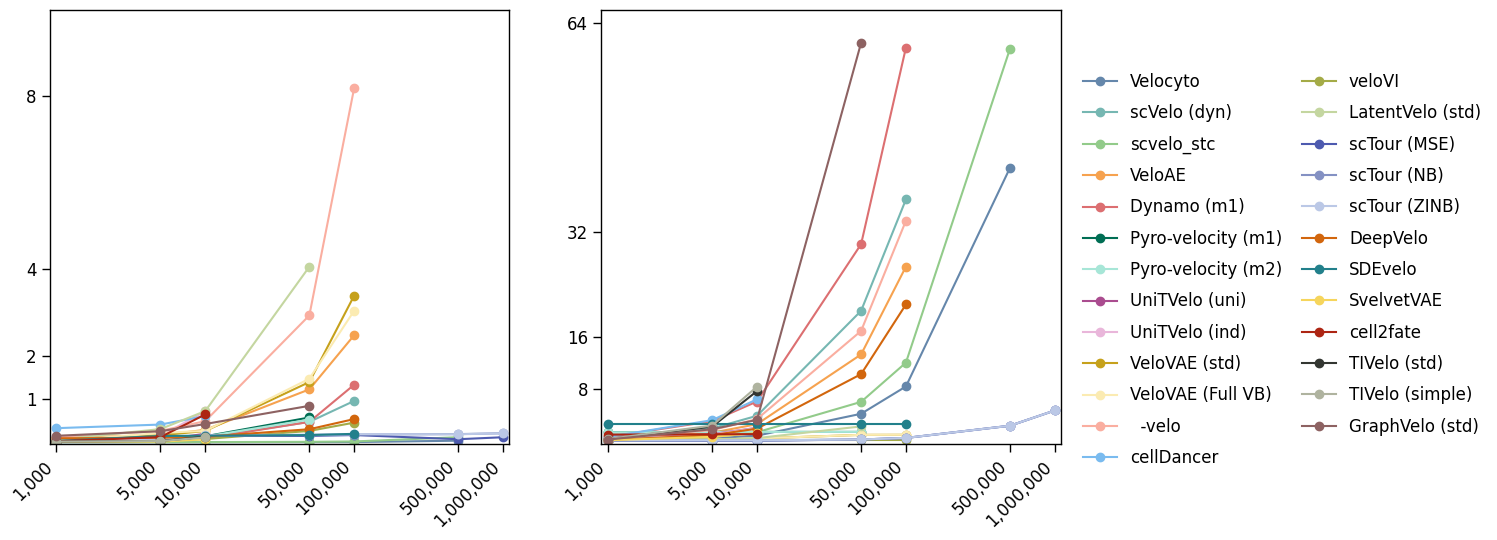

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
from matplotlib.font_manager import FontProperties

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax_time, ax_mem = axes

# ========= Time =========
for method in old_method_order:
    if method not in time_df.columns:
        continue

    y = time_df[method]
    mask = ~y.isna()
    if mask.sum() == 0:
        continue

    color = auto_color_map.get(method, "gray")
    label = newmethods.get(method, method)

    ax_time.plot(
        cell_nums[mask.values],
        y[mask].values,
        marker='o',
        color=color,
        label=label
    )

ax_time.set_xscale('log')
ax_time.xaxis.set_major_locator(FixedLocator(cell_nums))
ax_time.set_xticklabels(
    [f"{int(x):,}" for x in cell_nums],
    rotation=45,
    ha="right"
)
ax_time.set_xlim(cell_nums[0] * 0.9, cell_nums[-1] * 1.1)
ax_time.xaxis.set_minor_locator(plt.NullLocator())

ax_time.set_yticks([1, 2, 4, 8])
ax_time.set_ylim(-0.05, 10)
# ax_time.axhline(y=1, color='red', linestyle='--', linewidth=2)

set_axes_style(ax_time)

# ========= Memory =========
for method in old_method_order:
    if method not in memory_df.columns:
        continue

    y = memory_df[method]
    mask = ~y.isna()
    if mask.sum() == 0:
        continue

    color = auto_color_map.get(method, "gray")
    label = newmethods.get(method, method)

    ax_mem.plot(
        cell_nums[mask.values],
        y[mask].values,
        marker='o',
        color=color,
        label=label
    )

ax_mem.set_xscale('log')
ax_mem.xaxis.set_major_locator(FixedLocator(cell_nums))
ax_mem.set_xticklabels(
    [f"{int(x):,}" for x in cell_nums],
    rotation=45,
    ha="right"
)
ax_mem.set_xlim(cell_nums[0] * 9e-1, cell_nums[-1] * 1.1)
ax_mem.xaxis.set_minor_locator(plt.NullLocator())

ax_mem.set_yticks([8, 16, 32, 64])
ax_mem.set_ylim(-0.5, 66)
# ax_mem.axhline(y=8, color='red', linestyle='--', linewidth=2)

set_axes_style(ax_mem)

# ========= Legend =========
legend_font = FontProperties(size=12)

handles, labels = ax_time.get_legend_handles_labels()

ordered_handles = []
ordered_labels = []

for old in old_method_order:
    new = newmethods.get(old, old)
    if new in labels:
        idx = labels.index(new)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

if not ordered_handles:
    ordered_handles, ordered_labels = handles, labels

legend = fig.legend(
    ordered_handles,
    ordered_labels,
    ncol=2,
    loc='center right',
    bbox_to_anchor=(1.0, 0.5),   # ✅ 关键：legend 放进 figure
    prop=legend_font,
    frameon=False,
    labelspacing=0.8,
    columnspacing=1.2
)

# ========= Layout & Save =========
plt.tight_layout()
fig.subplots_adjust(right=0.71, wspace=0.2)  # ✅ 给 legend 足够空间

plt.savefig(
    "time_memory_cells.svg",
    format="svg",
    dpi=300
)

plt.show()


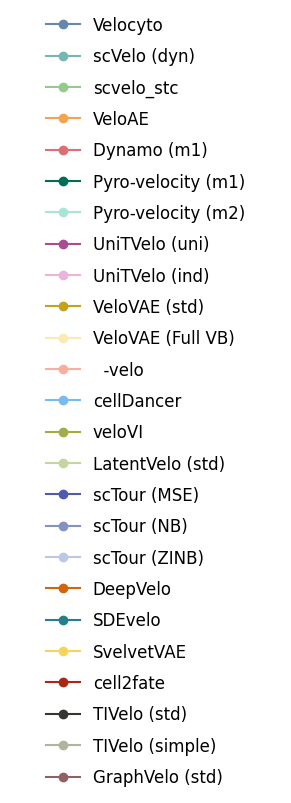

In [22]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

handles, labels = ax_time.get_legend_handles_labels()

ordered_handles = []
ordered_labels = []

for old in old_method_order:
    new = newmethods.get(old, old)
    if new in labels:
        idx = labels.index(new)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

if not ordered_handles:
    ordered_handles, ordered_labels = handles, labels

fig_legend = plt.figure(figsize=(3.5, 6))
legend_font = FontProperties(size=12)

fig_legend.legend(
    ordered_handles,
    ordered_labels,
    ncol=1,
    loc="center",
    frameon=False,
    prop=legend_font,
    labelspacing=0.8,
    handlelength=2.0
)

plt.axis("off")

plt.savefig(
    "methods_legend_1col.svg",
    format="svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## genes

In [23]:
time_tables = []
memory_tables = []

for method in old_method_order:
    file_path = f"genes/{method}_gene_results.csv"

    df = pd.read_csv(file_path)
    df.columns = ["genes", "execution_time_sec", "peak_memory_mb", "status"]

    df = df[df["status"] == "success"].copy()


    df["time_sec"] = df["execution_time_sec"] 

    df["memory_mb"] = df["peak_memory_mb"]
    time_tables.append(
        df[["genes", "time_sec"]]
        .set_index("genes")
        .rename(columns={"time_sec": method})
    )

    memory_tables.append(
        df[["genes", "memory_mb"]]
        .set_index("genes")
        .rename(columns={"memory_mb": method})
    )

time_df = pd.concat(time_tables, axis=1)
memory_df = pd.concat(memory_tables, axis=1)

time_df = time_df.reindex(columns=[m for m in old_method_order if m in time_df.columns])
memory_df = memory_df.reindex(columns=[m for m in old_method_order if m in memory_df.columns])
time_df = time_df.sort_index()
memory_df = memory_df.sort_index()


gene_levels = time_df.index.tolist()

rows = []

for method in old_method_order:
    if method not in time_df.columns:
        continue

    row = {"Method": method}

    for c in gene_levels:
        row[f"time_{c}(sec)"] = (
            time_df.loc[c, method] if c in time_df.index else np.nan
        )

    for c in gene_levels:
        row[f"mem_{c}(MB)"] = (
            memory_df.loc[c, method] if c in memory_df.index else np.nan
        )

    rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df["Method"] = pd.Categorical(
    summary_df["Method"],
    categories=[m for m in old_method_order if m in summary_df["Method"].values],
    ordered=True
)
summary_df = summary_df.sort_values("Method").reset_index(drop=True)

summary_df.to_csv("time_memory_by_method_genes.csv", index=False)

In [24]:
time_tables = []
memory_tables = []

for method in old_method_order:
    file_path = f"genes/{method}_gene_results.csv"

    df = pd.read_csv(file_path)
    df.columns = ["genes", "execution_time_sec", "peak_memory_mb", "status"]

    df = df[df["status"] == "success"].copy()

    df["time_hour"] = df["execution_time_sec"] / 60.0 / 60.0
    df["memory_gb"] = df["peak_memory_mb"] / 1024.0

    time_tables.append(
        df[["genes", "time_hour"]]
        .set_index("genes")
        .rename(columns={"time_hour": method})
    )

    memory_tables.append(
        df[["genes", "memory_gb"]]
        .set_index("genes")
        .rename(columns={"memory_gb": method})
    )

time_df = pd.concat(time_tables, axis=1)
memory_df = pd.concat(memory_tables, axis=1)

time_df = time_df.reindex(columns=[m for m in old_method_order if m in time_df.columns])
memory_df = memory_df.reindex(columns=[m for m in old_method_order if m in memory_df.columns])

time_df = time_df.sort_index()
memory_df = memory_df.sort_index()

time_df.to_csv("time_table_genes.csv")
memory_df.to_csv("memory_table_genes.csv")

print("Time table (hour):")
print(time_df.head())

print("\nMemory table (GB):")
print(memory_df.head())


Time table (hour):
       velocyto  scvelo_dyn  scvelo_stc    veloae  dynamo_m1  pyrovelocity_m1  \
genes                                                                           
1000   0.001687    0.104252    0.003144  0.287801   0.087183         0.137577   
2000   0.001330    0.129921    0.003435  0.279454   0.139091         0.181636   
5000   0.002459    0.242326    0.007127  0.347177   0.159773         0.495458   
10000  0.005231    0.647292    0.013277  0.457964   0.206011              NaN   
15000  0.007045    0.989792    0.019898  0.575010   0.246210              NaN   

       pyrovelocity_m2  unitvelo_uni  unitvelo_ind  velovae_std  ...  \
genes                                                            ...   
1000          0.132398      0.195134      0.717594     0.259596  ...   
2000          0.185616      0.391967      1.920036     0.318563  ...   
5000          0.492795      0.322389      2.095821     0.370488  ...   
10000              NaN      0.331610      2.454995   

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FixedLocator, ScalarFormatter
from matplotlib.font_manager import FontProperties

gene_nums = np.array(sorted(time_df.index))

colors_tab20 = list(cm.get_cmap("tab20").colors)
colors_set3 = list(cm.get_cmap("Dark2").colors)
fallback_colors = colors_tab20 + colors_set3

auto_color_map = {}
fallback_iter = iter(fallback_colors)

for m in old_method_order:
    if m in method_colors:
        auto_color_map[m] = method_colors[m]
    else:
        try:
            auto_color_map[m] = next(fallback_iter)
        except StopIteration:
            fallback_iter = iter(fallback_colors)
            auto_color_map[m] = next(fallback_iter)


/tmp/ipykernel_114698/581692737.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_tab20 = list(cm.get_cmap("tab20").colors)
/tmp/ipykernel_114698/581692737.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_set3 = list(cm.get_cmap("Dark2").colors)


In [26]:
def set_axes_style(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1)
    ax.tick_params(
        axis='both', which='major',
        direction='out', length=6, width=1,
        labelsize=12, bottom=True, left=True,
        top=False, right=False
    )
    ax.tick_params(
        axis='both', which='minor',
        direction='out', length=4, width=1,
        bottom=True, left=True,
        top=False, right=False
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')


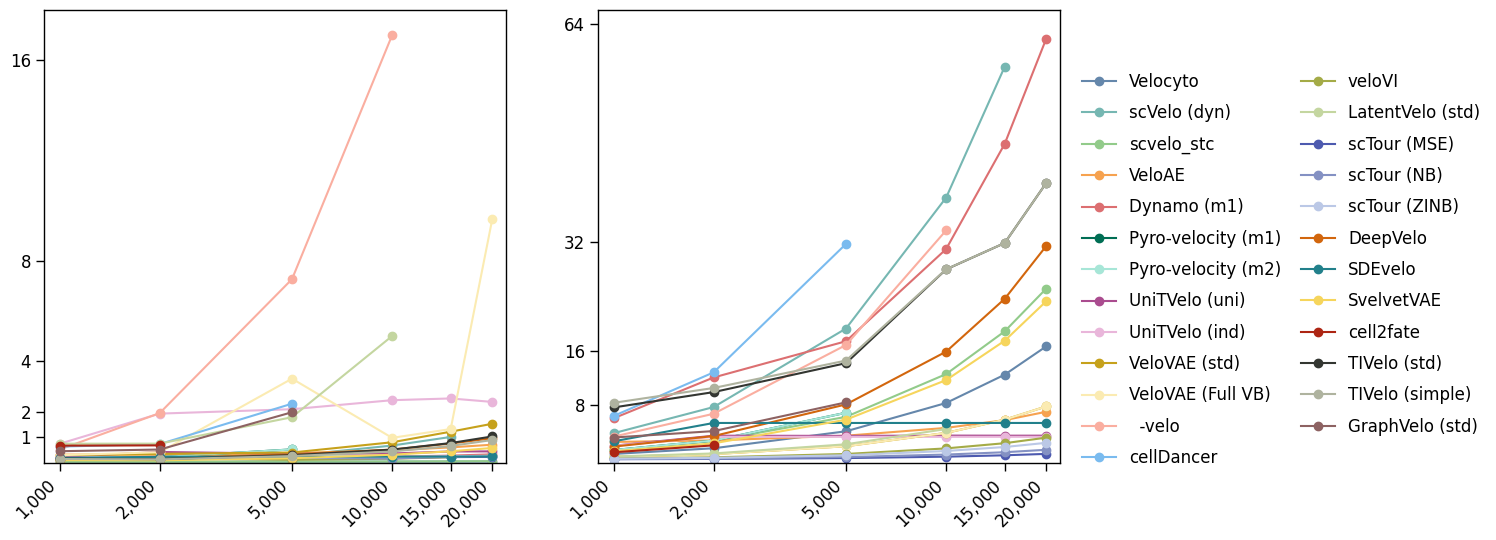

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
from matplotlib.font_manager import FontProperties

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax_time, ax_mem = axes

# ========= Time =========
for method in old_method_order:
    if method not in time_df.columns:
        continue

    y = time_df[method]
    mask = ~y.isna()
    if mask.sum() == 0:
        continue

    color = auto_color_map.get(method, "gray")
    label = newmethods.get(method, method)

    ax_time.plot(
        gene_nums[mask.values],
        y[mask].values,
        marker='o',
        color=color,
        label=label
    )

ax_time.set_xscale('log')
ax_time.xaxis.set_major_locator(FixedLocator(gene_nums))
ax_time.set_xticklabels(
    [f"{int(x):,}" for x in gene_nums],
    rotation=45,
    ha="right"
)
ax_time.set_xlim(gene_nums[0] * 0.9, gene_nums[-1] * 1.1)
ax_time.xaxis.set_minor_locator(plt.NullLocator())

ax_time.set_yticks([1, 2, 4, 8, 16])
ax_time.set_ylim(-0.05, 18)
# ax_time.axhline(y=1, color='red', linestyle='--', linewidth=2)

set_axes_style(ax_time)

# ========= Memory =========
for method in old_method_order:
    if method not in memory_df.columns:
        continue

    y = memory_df[method]
    mask = ~y.isna()
    if mask.sum() == 0:
        continue

    color = auto_color_map.get(method, "gray")
    label = newmethods.get(method, method)

    ax_mem.plot(
        gene_nums[mask.values],
        y[mask].values,
        marker='o',
        color=color,
        label=label
    )

ax_mem.set_xscale('log')
ax_mem.xaxis.set_major_locator(FixedLocator(gene_nums))
ax_mem.set_xticklabels(
    [f"{int(x):,}" for x in gene_nums],
    rotation=45,
    ha="right"
)
ax_mem.set_xlim(gene_nums[0] * 9e-1, gene_nums[-1] * 1.1)
ax_mem.xaxis.set_minor_locator(plt.NullLocator())

ax_mem.set_yticks([8, 16, 32, 64])
ax_mem.set_ylim(-0.5, 66)
# ax_mem.axhline(y=8, color='red', linestyle='--', linewidth=2)

set_axes_style(ax_mem)

# ========= Legend =========
legend_font = FontProperties(size=12)

handles, labels = ax_time.get_legend_handles_labels()

ordered_handles = []
ordered_labels = []

for old in old_method_order:
    new = newmethods.get(old, old)
    if new in labels:
        idx = labels.index(new)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

if not ordered_handles:
    ordered_handles, ordered_labels = handles, labels

legend = fig.legend(
    ordered_handles,
    ordered_labels,
    ncol=2,
    loc='center right',
    bbox_to_anchor=(1.0, 0.5),   # ✅ 关键：legend 放进 figure
    prop=legend_font,
    frameon=False,
    labelspacing=0.8,
    columnspacing=1.2
)

# ========= Layout & Save =========
plt.tight_layout()
fig.subplots_adjust(right=0.71, wspace=0.2)  # ✅ 给 legend 足够空间

plt.savefig(
    "time_memory_genes.svg",
    format="svg",
    dpi=300
)

plt.show()


## Real data

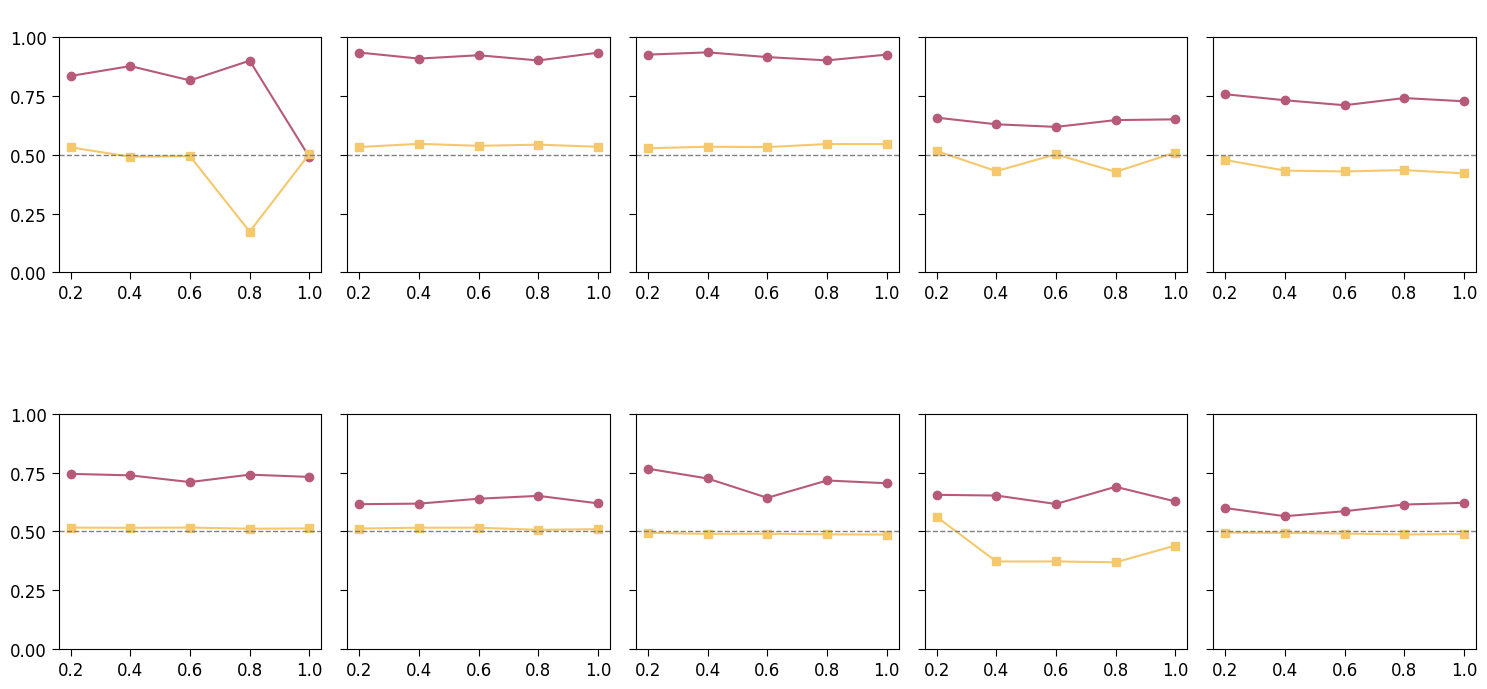

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


select_methods = [
    'sctour_mse', 'sctour_nb', 'sctour_zinb',
    'velocyto', 'scvelo_stc',
    'velovi', 'sdevelo',
    'velovae_fullvb', 'deepvelo', 'velovae_std'
]

downsample_levels = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
value_cols = ['0', '1', '2', '3', '4']

icvcoh_color = "#b75a79"
cto_color = "#f5c86c"

y_ticks = [0.0, 0.25, 0.50, 0.75, 1.00]


icvcoh_df = pd.read_csv("data07/icvcoh_df.csv")
cto_df = pd.read_csv("data16/cto_df.csv")

for df in (icvcoh_df, cto_df):
    df["Method"] = pd.Categorical(
        df["Method"],
        categories=select_methods,
        ordered=True
    )

icvcoh_df = icvcoh_df.sort_values("Method")
cto_df = cto_df.sort_values("Method")
icvcoh_df.to_csv("icvcoh_sorted.csv", index=False)
cto_df.to_csv("cto_sorted.csv", index=False)


fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 7),
    sharey='row'
)

for i, method in enumerate(select_methods):
    ax = axes[i // 5, i % 5]

    icvcoh_vals = icvcoh_df.loc[
        icvcoh_df["Method"] == method, value_cols
    ].values[0].astype(float)

    cto_vals = cto_df.loc[
        cto_df["Method"] == method, value_cols
    ].values[0].astype(float)

    ax.plot(downsample_levels, icvcoh_vals,
            marker='o', linewidth=1.5, color=icvcoh_color)
    ax.plot(downsample_levels, cto_vals,
            marker='s', linewidth=1.5, color=cto_color)

    ax.set_ylim(0, 1)
    ax.set_yticks(y_ticks)
    ax.axhline(0.5, linestyle='--', linewidth=1, color='gray')

    ax.set_title(" ", pad=10)

    ax.set_xticks(downsample_levels)
    ax.tick_params(axis='x', labelbottom=True, length=5, labelsize=12)

    if i in (0, 5):
        ax.tick_params(axis='y', labelleft=True, length=5, labelsize=12)
    else:
        ax.tick_params(axis='y', labelleft=False, length=5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.savefig('scalability_top10_supp.svg', format='svg', bbox_inches='tight')

plt.show()
